# Plot Diurnal Cycle Components of a 2D variable from at least 6 hourly data
- ## Models or observations
- ## Multiple resolution

In [16]:
import importlib
import sys
sys.path.insert(0, '/glade/work/rneale/git/python-scripts/diurnal_cycle')

import diurnal_cycle_utils as dcutils
importlib.reload(dcutils)

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import os

print('Imports OK')

Imports OK


In [17]:
from dask.distributed import Client
from dask_jobqueue import PBSCluster

In [18]:
cluster = PBSCluster(
    account="P03010039",
    interface="ext",
    walltime="12:00:00",
    queue="main",   
    cores=4,
    memory="32GB",
    processes=4,      # one process per core (safe default)
    local_directory="/glade/derecho/scratch/rneale/dask-temp"  # <--- custom temp dir
)

cluster.scale(jobs=4)
client = Client(cluster)

client

## Setup Run Information

/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46787 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Compute/proxy/46787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Compute/proxy/46787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.173:34355,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Compute/proxy/46787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [43]:
# ============================================================
# SETTINGS
# ============================================================

# --- Data source ---
data_src   = "CAM"      # 'TRMM' | 'IMERG' | 'ERA5' | 'CAM'
season     = 'JJA'
year_start = 31
year_end   = 50

# --- Plot domain ---
domain = 'CONUS'      # 'GLOBAL' | 'US' | 'TROPICS' | 'CONUS'
show_region_boxes     = True

_DOMAINS = {
    'GLOBAL':  {'lat_range': (-40.,  40.), 'lon_range': (-180., 180.)},
    'TROPICS': {'lat_range': (-30.,  15.), 'lon_range': (-180., 180.)}, # DJF   
    'US':      {'lat_range': ( 15.,  60.), 'lon_range': (-140.,  -55.)},
    'CONUS':   {'lat_range': ( 22.,  52.), 'lon_range': (-130.,  -65.)},
}
if domain not in _DOMAINS:
    raise ValueError(f"Unknown domain '{domain}'. Choose from: {list(_DOMAINS)}")
      
lat_range   = _DOMAINS[domain]['lat_range']
lon_range   = _DOMAINS[domain]['lon_range']

# Different domain for JJA in TROPICAL
if season == 'JJA' and domain == 'TROPICS': lat_range = (-10.,  35.)

show_states = domain in ('US', 'CONUS')

# TRMM 0.25-degree 3-hourly data
dir_trmm = '/glade/campaign/cgd/amp/rneale/data/TRMM/3hrly/0.25deg/'

# IMERG V07B 3-hourly data (choose resolution subdirectory)
dir_imerg = '/glade/derecho/scratch/rneale/IMERG/3hrly/0.25deg'
# dir_imerg = '/glade/derecho/scratch/rneale/IMERG/3hrly/1deg'

# ERA5: point to the directory of per-year clean 3-hourly files
#file_era5 = '/glade/derecho/scratch/rneale/ERA5/download/dcycle_3hrave/precip/precip_1979_era5_3hrave.nc'
file_era5 = '/glade/derecho/scratch/rneale/ERA5/download/dcycle_3hrave/precip/clean_3hr'

# CAM/CESM settings (used when data_src = 'CAM')
case_cam  = 'b.e30_alpha08b.B1850C_LTso.ne30_t232_wgx3.316'
hist_type = 'h3a'
dir_cam   = ('/glade/derecho/scratch/hannay/archive/'
             'b.e30_alpha08b.B1850C_LTso.ne30_t232_wgx3.316/atm/hist')
precip_vars_cam = ('PRECC', 'PRECL')

# --- Analysis ---
dt_hours = 3
n_harm   = 2

# --- Evans plot amplitude thresholds (mm/day) ---
min_amp_list = [0.0, 0.0]
max_amp_list = [4.0, 4.0]

# --- Raw diurnal max amplitude thresholds (mm/day) ---
min_amp_raw = 0.0
max_amp_raw = 4.0
hue_offset = 0.5
discrete_wheel = True

# --- Feature toggles ---
# show_region_lineplots : regional mean diurnal cycle line-plot panels
#   active for TROPICS (DJF/JJA) and CONUS (JJA)
# show_region_boxes     : annotate Evans/precip maps with bounding boxes
#   active for TROPICS (DJF/JJA) and CONUS (JJA)
show_region_lineplots = True


# --- Output ---
dir_fig = '/glade/u/home/rneale/python/python-figs/diurnal_cycle/'
os.makedirs(dir_fig, exist_ok=True)

harm_names   = ['Diurnal (H1, 24h)', 'Semi-diurnal (H2, 12h)']
harm_periods = [24.0, 12.0]
harm_fnames  = ['H1_diurnal', 'H2_semidiurnal']

print(f'Settings: {data_src}  {season}  {year_start}-{year_end}  domain={domain}')
print(f'  lat_range={lat_range}  lon_range={lon_range}  show_states={show_states}')
print(f'  amp range: {min_amp_list[0]}–{max_amp_list[0]} mm/day')
print(f'  show_region_lineplots={show_region_lineplots}  show_region_boxes={show_region_boxes}')

Settings: CAM  JJA  31-50  domain=CONUS
  lat_range=(22.0, 52.0)  lon_range=(-130.0, -65.0)  show_states=True
  amp range: 0.0–4.0 mm/day
  show_region_lineplots=True  show_region_boxes=True


In [44]:
# ============================================================
# REGIONAL AVERAGING BOXES
# lon_box uses 0-360 convention for tropical regions.
# CONUS regions use ±180 convention (negative longitudes).
# mask_type : 'land' | 'ocean' | None (all points)
# land_only : True  →  treated as mask_type='land'  (legacy)
# ============================================================

# --- DJF: Maritime Continent land sub-regions ---
djf_regions_mc_land = [
    {'name': 'Sumatra',         'lat_box': (-6.,  6.),  'lon_box': ( 95., 110.), 'land_only': True},
    {'name': 'Borneo',          'lat_box': (-4.,  7.),  'lon_box': (108., 120.), 'land_only': True},
    {'name': 'Java',            'lat_box': (-9., -5.),  'lon_box': (105., 116.), 'land_only': True},
    {'name': 'Sulawesi/Maluku', 'lat_box': (-5.,  4.),  'lon_box': (119., 131.), 'land_only': True},
    {'name': 'New Guinea',      'lat_box': (-8.,  0.),  'lon_box': (131., 148.), 'land_only': True},
]

# --- DJF: Maritime Continent surrounding ocean sub-regions ---
djf_regions_mc_ocean = [
    {'name': 'S. China Sea',    'lat_box': ( 3., 20.),  'lon_box': (110., 122.), 'land_only': False},
    {'name': 'Java/Banda Sea',  'lat_box': (-8., -2.),  'lon_box': (108., 135.), 'land_only': False},
    {'name': 'Timor Sea',       'lat_box': (-13., -7.), 'lon_box': (123., 136.), 'land_only': False},
]

# --- DJF: other tropical regions ---
djf_regions_other = [
    {'name': 'C. South America','lat_box': (-20.,  0.), 'lon_box': (285., 315.), 'land_only': True},
    {'name': 'C. Africa',       'lat_box': (-15.,  0.), 'lon_box': (  8.,  42.), 'land_only': True},
    {'name': 'W. Pacific',      'lat_box': (-15., 10.), 'lon_box': (160., 200.), 'land_only': False},
]

# --- JJA: Indian subcontinent ---
jja_regions = [
    {'name': 'India',           'lat_box': (  5., 30.), 'lon_box': ( 65.,  90.), 'land_only': True},
]

# --- CONUS / JJA: matching regions from forecast_diurnal_main.ipynb ---
# lon_box in ±180 convention (negative = western hemisphere)
conus_jja_regions = [
    {'name': 'Midwest',         'lat_box': (35., 45.), 'lon_box': (-100., -90.), 'mask_type': None},
    {'name': 'Southeast US',    'lat_box': (25., 35.), 'lon_box': ( -92., -80.), 'mask_type': 'land'},
    {'name': 'SE Coast Ocean',  'lat_box': (30., 35.), 'lon_box': ( -80., -70.), 'mask_type': 'ocean'},
]

# Build combined annotation list for the current season/domain
_regions_annotate = []
if domain == 'TROPICS':
    if season == 'DJF':
        _regions_annotate = djf_regions_mc_land + djf_regions_mc_ocean + djf_regions_other
    elif season == 'JJA':
        _regions_annotate = jja_regions
elif domain == 'CONUS' and season == 'JJA':
    _regions_annotate = conus_jja_regions

print(f'Region boxes defined: {len(_regions_annotate)} for {domain}/{season}')
land_count  = sum(1 for r in _regions_annotate if r.get('mask_type') == 'land'  or r.get('land_only', False))
ocean_count = sum(1 for r in _regions_annotate if r.get('mask_type') == 'ocean')
print(f'  {land_count} land-only, {ocean_count} ocean-only, '
      f'{len(_regions_annotate)-land_count-ocean_count} all-points')

Region boxes defined: 3 for CONUS/JJA
  1 land-only, 1 ocean-only, 1 all-points


In [45]:
importlib.reload(dcutils)

# ============================================================
# LOAD DATA AND COMPUTE COMPOSITE DIURNAL CYCLE
# ============================================================

data_src_upper = data_src.upper()

if data_src_upper == 'TRMM':
    print(f'Loading TRMM {season} {year_start}-{year_end} ...')
    dc = dcutils.load_trmm_composite(dir_trmm, year_start, year_end,
                                      season=season, dt_hours=dt_hours)
elif data_src_upper == 'IMERG':
    print(f'Loading IMERG {season} {year_start}-{year_end} from {dir_imerg} ...')
    dc = dcutils.load_imerg_composite(dir_imerg, year_start, year_end,
                                       season=season, dt_hours=dt_hours)
elif data_src_upper == 'ERA5':
    print(f'Loading ERA5 {season} ...')
    dc = dcutils.load_era5_composite(file_era5, season=season)
elif data_src_upper == 'CAM':
    print(f'Loading CAM {case_cam} {hist_type} {season} {year_start}-{year_end} ...')
    dc = dcutils.load_cam_composite(
        dir_cam, case_cam,
        hist_type   = hist_type,
        year_start  = year_start,
        year_end    = year_end,
        season      = season,
        dt_hours    = dt_hours,
        precip_vars = precip_vars_cam,
    )
else:
    raise ValueError(f"Unknown data_src: '{data_src}'. Choose from: TRMM, IMERG, ERA5, CAM")

lat = dc['lat'].values
lon = dc['lon'].values
print(f'\nDiurnal cycle shape: {dc.shape}')
print(f'Lat: {lat[0]:.2f} to {lat[-1]:.2f}')
print(f'Lon: {lon[0]:.2f} to {lon[-1]:.2f}')
print(f'Time-of-day (UTC h): {dc["time_of_day"].values}')
print(f'Mean precip range: {float(np.nanmin(dc.mean("time_of_day"))):.2f} '
      f'to {float(np.nanmax(dc.mean("time_of_day"))):.2f} mm/day')

Loading CAM b.e30_alpha08b.B1850C_LTso.ne30_t232_wgx3.316 h3a JJA 31-50 ...
  CAM h3a: 7227 files found
  Year range 31–50: 1460 files
  Season JJA: 14720 steps selected
  Computing diurnal composite via dask groupby...

Diurnal cycle shape: (8, 192, 288)
Lat: -90.00 to 90.00
Lon: 0.00 to 358.75
Time-of-day (UTC h): [ 0.  3.  6.  9. 12. 15. 18. 21.]
Mean precip range: 0.00 to 25.75 mm/day


In [46]:
# ============================================================
# FFT HARMONIC ANALYSIS + LOCAL SOLAR TIME PHASE
# ============================================================

amplitude, phase_utc, var_exp, mean_prcp = dcutils.compute_harmonics(
    dc, n_harm=n_harm, dt_hours=dt_hours)

# Convert UTC phase → local solar time for each harmonic
phase_lst = np.zeros_like(phase_utc)
for ih in range(n_harm):
    period_h = harm_periods[ih]
    phase_lst[ih] = dcutils.phase_utc_to_lst(phase_utc[ih], lon, period_h)

print('Harmonic analysis complete.')
for ih in range(n_harm):
    print(f'  H{ih+1} ({harm_names[ih]}): '
          f'amp max={np.nanmax(amplitude[ih]):.2f} mm/day, '
          f'var_exp mean={np.nanmean(var_exp[ih]):.1%}')

Harmonic analysis complete.
  H1 (Diurnal (H1, 24h)): amp max=10.92 mm/day, var_exp mean=81.6%
  H2 (Semi-diurnal (H2, 12h)): amp max=2.61 mm/day, var_exp mean=15.1%


In [47]:
# ============================================================
# LAND MASK  (used for land_only / ocean_only regional averages)
# Built once here; takes a few seconds at 110m scale.
# ============================================================

_needs_mask = (
    (domain == 'TROPICS' and show_region_lineplots) or
    (domain == 'CONUS'   and season == 'JJA' and show_region_lineplots)
)

if _needs_mask:
    land_mask_grid = dcutils.get_land_mask(lat, lon, scale='110m')
    print(f'Land mask computed: {land_mask_grid.shape}, '
          f'{land_mask_grid.sum()} land points')
else:
    land_mask_grid = None
    print('Land mask skipped (not needed for current settings)')

  Building land mask (Natural Earth 110m) … 18402 land / 55296 total (33.3%)
Land mask computed: (192, 288), 18402 land points


terrain_r
Saved: /glade/u/home/rneale/python/python-figs/diurnal_cycle/CAM_CONUS_JJA_31-50_mean_precip.png


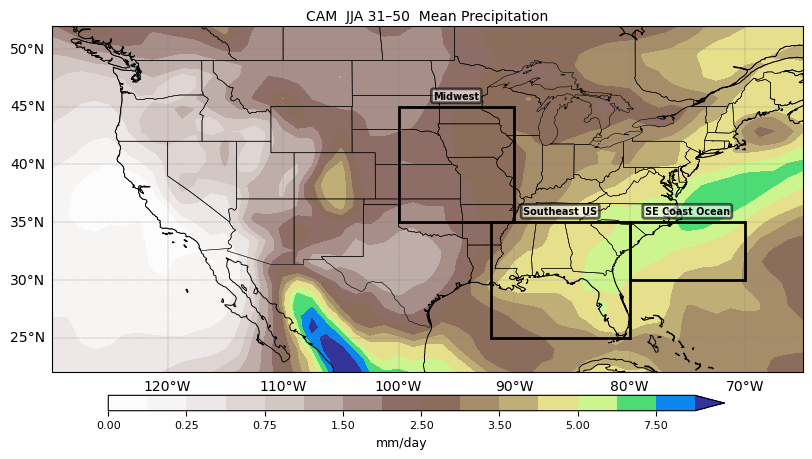

In [48]:
# ============================================================
# FIGURE 1: Mean Precipitation
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5),
                        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

cf = dcutils.plot_mean_precip(
    ax, mean_prcp, lat, lon,
    title=f'{data_src}  {season} {year_start}–{year_end}  Mean Precipitation',
    lat_range=lat_range, lon_range=lon_range,
    show_states=show_states,
)

if show_region_boxes and _regions_annotate:
    dcutils.annotate_regions_on_map(ax, _regions_annotate)

cbar = fig.colorbar(cf, ax=ax, orientation='horizontal',
                    pad=0.06, fraction=0.04, aspect=40)
cbar.set_label('mm/day', fontsize=9)
cbar.ax.tick_params(labelsize=8)

fname = os.path.join(dir_fig, f'{data_src}_{domain}_{season}_{year_start}-{year_end}_mean_precip.png')
fig.savefig(fname, dpi=150, bbox_inches='tight')
print(f'Saved: {fname}')
plt.show()

Saved: /glade/u/home/rneale/python/python-figs/diurnal_cycle/CAM_CONUS_JJA_31-50_evans_H1_diurnal.png


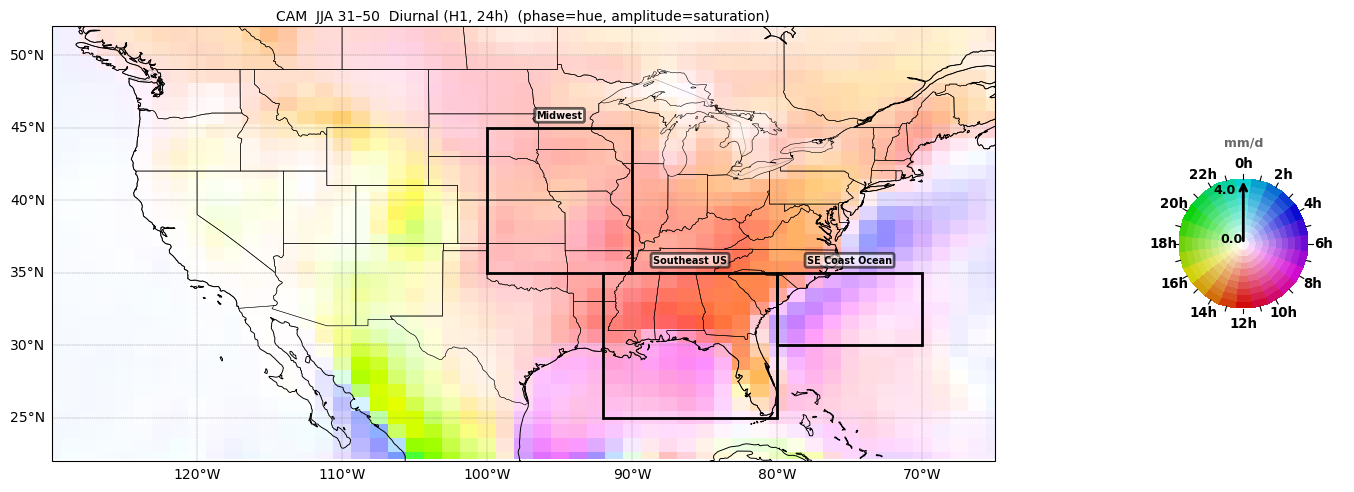

Saved: /glade/u/home/rneale/python/python-figs/diurnal_cycle/CAM_CONUS_JJA_31-50_evans_H2_semidiurnal.png


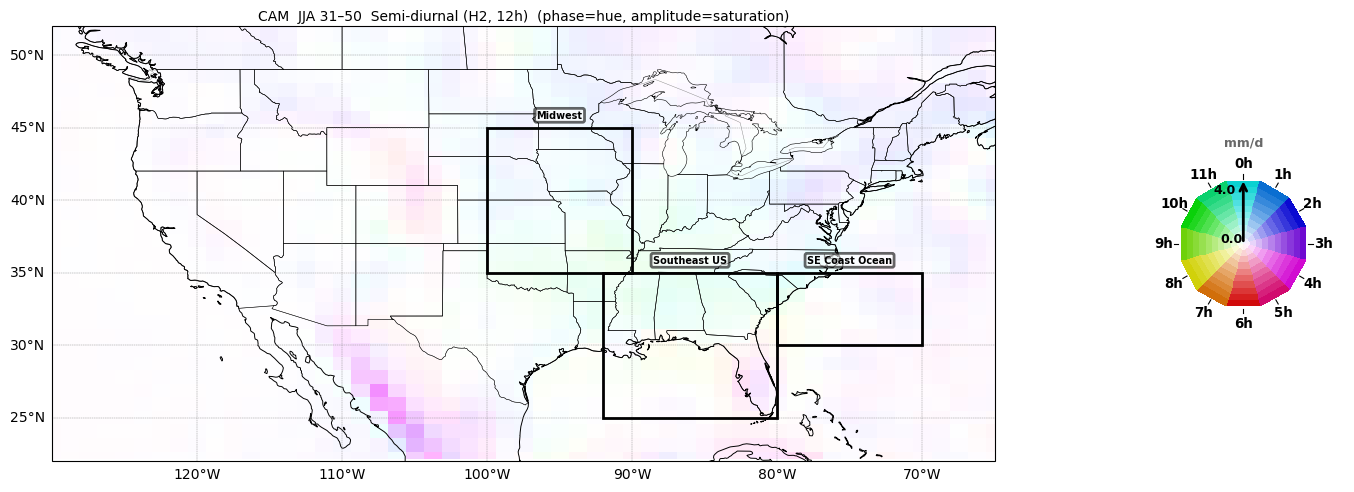

In [49]:
# ============================================================
# FIGURES 2+: Evans phase/amplitude maps for each harmonic
# ============================================================
import matplotlib.gridspec as gridspec

for ih in range(n_harm):
    period_h = harm_periods[ih]
    min_amp  = min_amp_list[ih]
    max_amp  = max_amp_list[ih]
    hname    = harm_names[ih]
    hfname   = harm_fnames[ih]

    fig = plt.figure(figsize=(15, 5))
    gs  = gridspec.GridSpec(
        1, 2, figure=fig,
        width_ratios=[7, 1.15],
        left=0.03, right=0.99,
        bottom=0.08, top=0.95,
        wspace=0.0,
    )
    ax       = fig.add_subplot(gs[0], projection=ccrs.PlateCarree(central_longitude=180))
    ax_wheel = fig.add_subplot(gs[1], projection='polar')

    dcutils.plot_evans_map(
        ax, fig,
        phase_lst    = phase_lst[ih],
        amplitude    = amplitude[ih],
        lat=lat, lon=lon,
        min_amp      = min_amp,
        max_amp      = max_amp,
        period_hours = period_h,
        title        = (f'{data_src}  {season} {year_start}\u2013{year_end}  '
                        f'{hname}  (phase=hue, amplitude=saturation)'),
        hue_offset     = hue_offset,
        lat_range      = lat_range,
        lon_range      = lon_range,
        ax_wheel       = ax_wheel,
        discrete_wheel = discrete_wheel,
        dt_hours       = dt_hours,
        show_states    = show_states,
    )

    if show_region_boxes and _regions_annotate:
        dcutils.annotate_regions_on_map(ax, _regions_annotate)

    fname = os.path.join(dir_fig,
                         f'{data_src}_{domain}_{season}_{year_start}-{year_end}_evans_{hfname}.png')
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    print(f'Saved: {fname}')
    plt.show()

Saved: /glade/u/home/rneale/python/python-figs/diurnal_cycle/CAM_CONUS_JJA_31-50_evans_raw_max.png


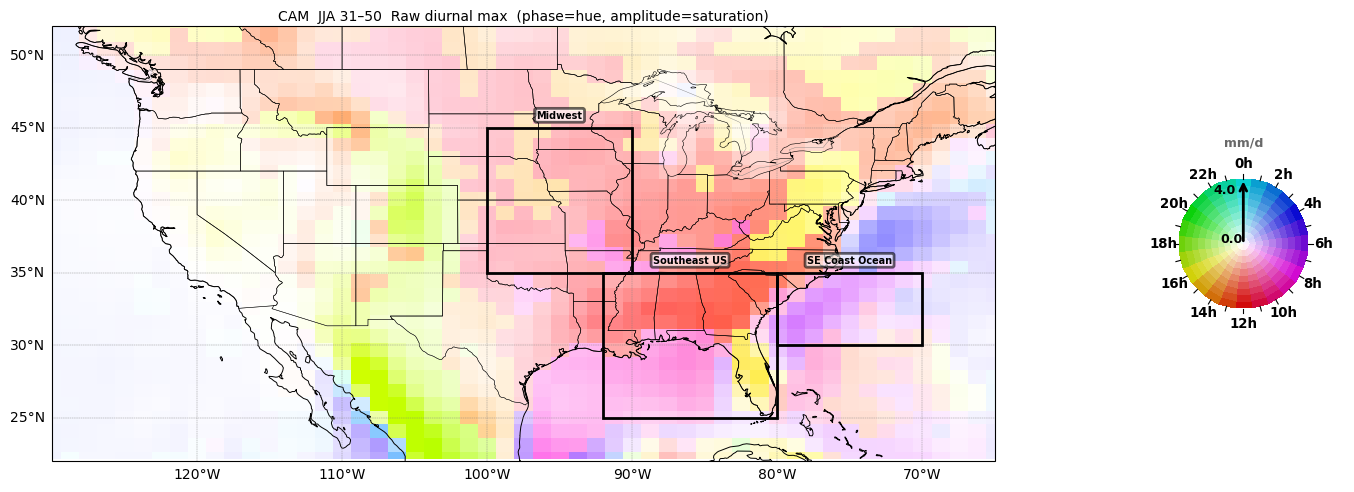

In [50]:
# ============================================================
# FIGURE 3: Raw diurnal cycle maximum — amplitude and phase
# ============================================================
import matplotlib.gridspec as gridspec

amp_raw, phase_utc_raw = dcutils.compute_raw_diurnal(dc, dt_hours=dt_hours)
phase_lst_raw = dcutils.phase_utc_to_lst(phase_utc_raw, lon, 24.0)

fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(
    1, 2, figure=fig,
    width_ratios=[7, 1.15],
    left=0.03, right=0.99,
    bottom=0.08, top=0.95,
    wspace=0.0,
)
ax       = fig.add_subplot(gs[0], projection=ccrs.PlateCarree(central_longitude=180))
ax_wheel = fig.add_subplot(gs[1], projection='polar')

dcutils.plot_evans_map(
    ax, fig,
    phase_lst    = phase_lst_raw,
    amplitude    = amp_raw,
    lat=lat, lon=lon,
    min_amp      = min_amp_raw,
    max_amp      = max_amp_raw,
    period_hours = 24.0,
    title        = (f'{data_src}  {season} {year_start}–{year_end}  '
                    f'Raw diurnal max  (phase=hue, amplitude=saturation)'),
    hue_offset     = hue_offset,
    lat_range      = lat_range,
    lon_range      = lon_range,
    ax_wheel       = ax_wheel,
    discrete_wheel = discrete_wheel,
    dt_hours       = dt_hours,
    show_states    = show_states,
)

if show_region_boxes and _regions_annotate:
    dcutils.annotate_regions_on_map(ax, _regions_annotate)

fname = os.path.join(dir_fig,
                     f'{data_src}_{domain}_{season}_{year_start}-{year_end}_evans_raw_max.png')
fig.savefig(fname, dpi=150, bbox_inches='tight')
print(f'Saved: {fname}')
plt.show()

In [51]:
# ============================================================
# REGIONAL LINE PLOTS: Maritime Continent — land + ocean
# (TROPICS / DJF only; gated by show_region_lineplots)
# ============================================================
importlib.reload(dcutils)

if domain == 'TROPICS' and season == 'DJF' and show_region_lineplots:
    mc_regions = djf_regions_mc_land + djf_regions_mc_ocean

    fig_mc = dcutils.plot_diurnal_region_group(
        dc, lat, lon, mc_regions,
        dt_hours   = dt_hours,
        n_harm     = n_harm,
        title      = (f'{data_src}  {season} {year_start}–{year_end}  '
                      f'Maritime Continent — land (top) & ocean (bottom)'),
        ncols      = 5,
        land_mask  = land_mask_grid,
    )
    fname_mc = os.path.join(
        dir_fig,
        f'{data_src}_{domain}_{season}_{year_start}-{year_end}_regions_MC.png')
    fig_mc.savefig(fname_mc, dpi=150, bbox_inches='tight')
    print(f'Saved: {fname_mc}')
    plt.show()
else:
    print(f'Skipping MC regional plots '
          f'(requires domain=TROPICS + season=DJF + show_region_lineplots=True; '
          f'got {domain}/{season}, show={show_region_lineplots})')

Skipping MC regional plots (requires domain=TROPICS + season=DJF + show_region_lineplots=True; got CONUS/JJA, show=True)


In [52]:
# ============================================================
# REGIONAL LINE PLOTS: Other tropical regions
# (C. South America, C. Africa, W. Pacific)
# (TROPICS / DJF only; gated by show_region_lineplots)
# ============================================================

if domain == 'TROPICS' and season == 'DJF' and show_region_lineplots:
    fig_other = dcutils.plot_diurnal_region_group(
        dc, lat, lon, djf_regions_other,
        dt_hours  = dt_hours,
        n_harm    = n_harm,
        title     = (f'{data_src}  {season} {year_start}–{year_end}  '
                     f'Tropical Regions'),
        ncols     = 3,
        land_mask = land_mask_grid,
    )
    fname_other = os.path.join(
        dir_fig,
        f'{data_src}_{domain}_{season}_{year_start}-{year_end}_regions_tropical.png')
    fig_other.savefig(fname_other, dpi=150, bbox_inches='tight')
    print(f'Saved: {fname_other}')
    plt.show()
else:
    print(f'Skipping other tropical region plots '
          f'(requires domain=TROPICS + season=DJF + show_region_lineplots=True; '
          f'got {domain}/{season}, show={show_region_lineplots})')

Skipping other tropical region plots (requires domain=TROPICS + season=DJF + show_region_lineplots=True; got CONUS/JJA, show=True)


In [53]:
# ============================================================
# REGIONAL LINE PLOTS: India
# (TROPICS / JJA only; gated by show_region_lineplots)
# ============================================================

if domain == 'TROPICS' and season == 'JJA' and show_region_lineplots:
    fig_india = dcutils.plot_diurnal_region_group(
        dc, lat, lon, jja_regions,
        dt_hours  = dt_hours,
        n_harm    = n_harm,
        title     = (f'{data_src}  {season} {year_start}–{year_end}  '
                     f'India'),
        ncols     = 1,
        land_mask = land_mask_grid,
    )
    fname_india = os.path.join(
        dir_fig,
        f'{data_src}_{domain}_{season}_{year_start}-{year_end}_regions_India.png')
    fig_india.savefig(fname_india, dpi=150, bbox_inches='tight')
    print(f'Saved: {fname_india}')
    plt.show()
else:
    print(f'Skipping India regional plot '
          f'(requires domain=TROPICS + season=JJA + show_region_lineplots=True; '
          f'got {domain}/{season}, show={show_region_lineplots})')

Skipping India regional plot (requires domain=TROPICS + season=JJA + show_region_lineplots=True; got CONUS/JJA, show=True)


/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:394: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:394: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:394: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/glade/work/rneale/git/python-scripts/diurnal_cycle/diurnal_cycle_utils.py:1461: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might b

Saved: /glade/u/home/rneale/python/python-figs/diurnal_cycle/CAM_CONUS_JJA_31-50_regions_CONUS.png


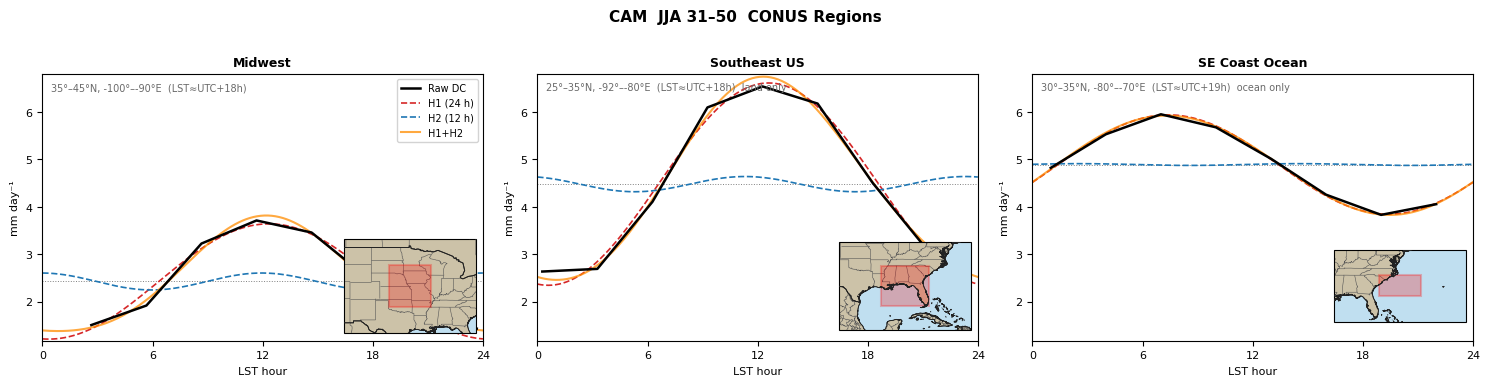

In [54]:
# ============================================================
# REGIONAL LINE PLOTS: CONUS regions (Midwest, SE US, SE Coast Ocean)
# (CONUS / JJA only; gated by show_region_lineplots)
# ============================================================
importlib.reload(dcutils)

if domain == 'CONUS' and season == 'JJA' and show_region_lineplots:
    fig_conus = dcutils.plot_diurnal_region_group(
        dc, lat, lon, conus_jja_regions,
        dt_hours    = dt_hours,
        n_harm      = n_harm,
        title       = (f'{data_src}  {season} {year_start}–{year_end}  '
                       f'CONUS Regions'),
        ncols       = 3,
        land_mask   = land_mask_grid,
        show_states = True,
    )
    fname_conus = os.path.join(
        dir_fig,
        f'{data_src}_{domain}_{season}_{year_start}-{year_end}_regions_CONUS.png')
    fig_conus.savefig(fname_conus, dpi=150, bbox_inches='tight')
    print(f'Saved: {fname_conus}')
    plt.show()
else:
    print(f'Skipping CONUS regional plots '
          f'(requires domain=CONUS + season=JJA + show_region_lineplots=True; '
          f'got {domain}/{season}, show={show_region_lineplots})')